# Momentum strategy comparison

Compare configurable momentum allocation variants against the baseline strategies from the validation notebook. All strategies are evaluated on a common date window aligned to the longest momentum warmup period.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from asset_allocation.backtest import run_backtest
from asset_allocation.config import BacktestConfig
from asset_allocation.data import load_prices
from asset_allocation.metrics import summary
from asset_allocation.plotting import (
    plot_allocation,
    plot_drawdown,
    plot_equity_curve,
    plot_summary,
)
from asset_allocation.strategy import (
    buy_and_hold_weights,
    constant_weights,
    momentum_weights,
    periodic_weights,
)
from asset_allocation.walkforward import walk_forward

%matplotlib inline

## Load prices

In [2]:
prices_full = load_prices()
print(
    f"Full sample: {len(prices_full)} months | "
    f"{prices_full.index[0].date()} -> {prices_full.index[-1].date()}"
)

Full sample: 342 months | 1997-12-31 -> 2026-05-29


## Strategy definitions

**Baselines** (from validation notebook):
- 100% momentum / 100% value
- 50/50 annual rebalance
- 50/50 buy-and-hold

**Momentum variants** vary lookback windows, volatility scaling, winner vs relative allocation, momentum-gap thresholds, and optional absolute (cash) mode.

In [3]:
BASELINE_STRATEGIES = {
    "100% momentum": lambda p: constant_weights(p, {"momentum": 1.0}),
    "100% value": lambda p: constant_weights(p, {"value": 1.0}),
    "50/50 annual": lambda p: periodic_weights(p, {"momentum": 0.5, "value": 0.5}, freq="Y"),
    "50/50 buy-and-hold": lambda p: buy_and_hold_weights(p, {"momentum": 0.5, "value": 0.5}),
}

MOMENTUM_CONFIGS: dict[str, dict] = {
    "mom 12m winner": {"lookbacks": (12,), "allocation": "winner"},
    "mom 12m relative": {"lookbacks": (12,), "allocation": "relative"},
    "mom 6m winner": {"lookbacks": (6,), "allocation": "winner"},
    "mom 3m winner": {"lookbacks": (3,), "allocation": "winner"},
    "mom 6+12 blend winner": {"lookbacks": (6, 12), "allocation": "winner"},
    "mom 6+12 blend relative": {"lookbacks": (6, 12), "allocation": "relative"},
    "mom 12m vol-scaled winner": {
        "lookbacks": (12,),
        "vol_scaled": True,
        "allocation": "winner",
    },
    "mom 12m vol-scaled relative": {
        "lookbacks": (12,),
        "vol_scaled": True,
        "allocation": "relative",
    },
    "mom 6+12 vol-scaled winner": {
        "lookbacks": (6, 12),
        "vol_scaled": True,
        "allocation": "winner",
    },
    "mom 6+12 vol-scaled relative": {
        "lookbacks": (6, 12),
        "vol_scaled": True,
        "allocation": "relative",
    },
    "mom 12m winner gap 2%": {
        "lookbacks": (12,),
        "allocation": "winner",
        "threshold": 0.02,
    },
    "mom 12m vol-scaled gap 2%": {
        "lookbacks": (12,),
        "vol_scaled": True,
        "allocation": "winner",
        "threshold": 0.02,
    },
    "mom 12m absolute (cash)": {
        "lookbacks": (12,),
        "allocation": "winner",
        "absolute": True,
    },
}


def first_rebalance_date(prices: pd.DataFrame, **kwargs) -> pd.Timestamp:
    weights = momentum_weights(prices, **kwargs)
    defined = weights.dropna(how="all")
    if defined.empty:
        raise ValueError(f"No rebalance dates for config: {kwargs}")
    return defined.index[0]


common_start = max(
    first_rebalance_date(prices_full, **cfg) for cfg in MOMENTUM_CONFIGS.values()
)
prices = prices_full.loc[common_start:].copy()
print(f"Common comparison window: {prices.index[0].date()} -> {prices.index[-1].date()} ({len(prices)} months)")

Common comparison window: 2000-12-29 -> 2026-05-29 (306 months)


In [4]:
strategies: dict[str, pd.DataFrame] = {}

for name, builder in BASELINE_STRATEGIES.items():
    strategies[name] = builder(prices)

for name, cfg in MOMENTUM_CONFIGS.items():
    strategies[name] = momentum_weights(prices, **cfg)

config = BacktestConfig()

## Run backtests (German taxes & costs)

In [5]:
results = {
    name: run_backtest(prices, weights, config)
    for name, weights in strategies.items()
}

summary_df = pd.concat([summary(r, name) for name, r in results.items()])
summary_df = summary_df.sort_values("sharpe_ratio", ascending=False)

summary_df.style.format(
    {
        "total_return": "{:.1%}",
        "cagr": "{:.1%}",
        "annual_volatility": "{:.1%}",
        "sharpe_ratio": "{:.2f}",
        "sortino_ratio": "{:.2f}",
        "calmar_ratio": "{:.2f}",
        "max_drawdown": "{:.1%}",
        "best_month": "{:.1%}",
        "worst_month": "{:.1%}",
        "win_rate": "{:.1%}",
        "annual_turnover": "{:.2f}",
        "time_in_market": "{:.1%}",
        "total_taxes": "{:,.0f}",
        "total_costs": "{:,.0f}",
    },
    na_rep="-",
)

,total_return,cagr,annual_volatility,sharpe_ratio,sortino_ratio,calmar_ratio,max_drawdown,longest_drawdown_months,best_month,worst_month,win_rate,annual_turnover,time_in_market,num_trades,total_taxes,total_costs
name,,,,,,,,,,,,,,,,
mom 12m absolute (cash),1442.1%,11.4%,12.5%,0.92,1.22,0.49,-23.2%,39,13.8%,-11.3%,53.1%,2.94,78.8%,62,"32,691","3,448"
mom 12m winner,1624.6%,11.9%,15.5%,0.80,1.05,0.22,-52.8%,62,13.8%,-16.7%,63.0%,2.62,95.8%,58,"37,406","2,884"
mom 6m winner,1568.4%,11.7%,15.7%,0.79,1.11,0.22,-53.4%,62,13.8%,-16.7%,63.6%,3.43,97.7%,90,"37,481","3,762"
mom 12m vol-scaled gap 2%,1326.0%,11.0%,14.7%,0.79,0.99,0.21,-53.3%,63,13.8%,-16.7%,58.0%,2.66,87.9%,54,"30,679","2,419"
mom 12m vol-scaled winner,1326.0%,11.0%,14.7%,0.79,0.99,0.21,-53.3%,63,13.8%,-16.7%,58.0%,2.66,87.9%,54,"30,679","2,419"
mom 6+12 blend winner,1512.3%,11.6%,15.5%,0.79,1.02,0.22,-53.4%,62,13.8%,-16.7%,63.0%,3.20,95.8%,66,"34,351","3,471"
mom 12m winner gap 2%,1482.8%,11.5%,15.5%,0.78,1.02,0.22,-52.8%,62,13.8%,-16.7%,62.0%,1.49,95.8%,34,"33,155","1,514"
mom 3m winner,1369.5%,11.2%,15.9%,0.75,0.99,0.19,-58.5%,75,13.8%,-20.9%,63.0%,4.90,98.7%,138,"34,582","4,462"
mom 6+12 vol-scaled winner,1044.5%,10.1%,14.8%,0.73,0.92,0.19,-53.4%,62,13.8%,-16.7%,57.4%,3.25,87.9%,66,"25,664","2,715"


## Baselines vs top momentum variants

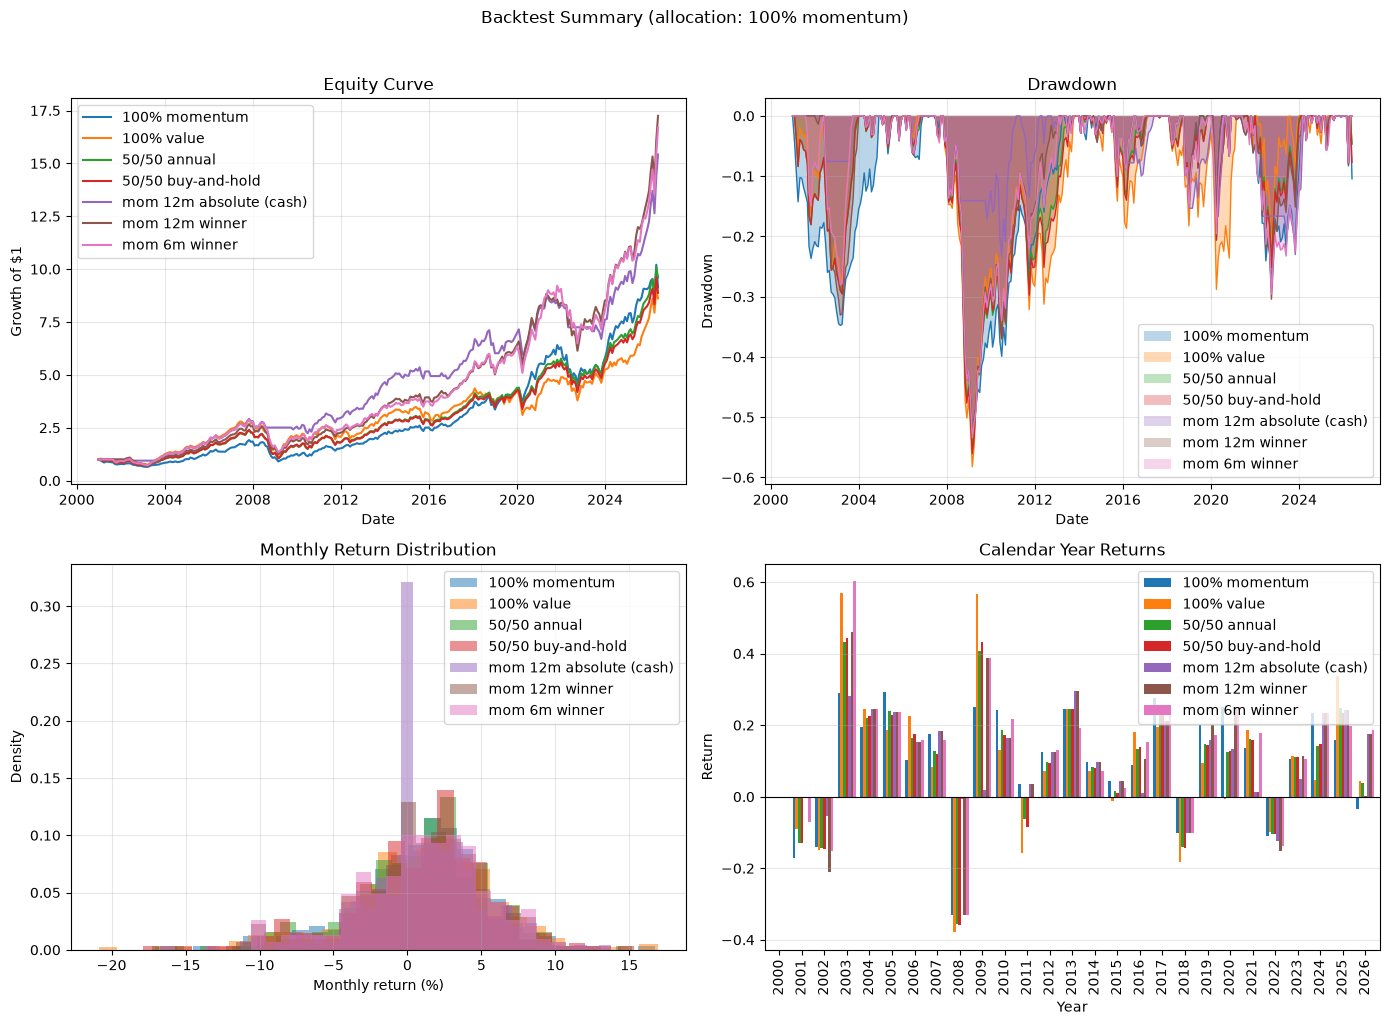

In [6]:
top_momentum = summary_df.drop(BASELINE_STRATEGIES.keys()).head(3).index.tolist()
focus_names = list(BASELINE_STRATEGIES.keys()) + top_momentum
focus_results = {name: results[name] for name in focus_names}

plot_summary(focus_results)
plt.show()

## Momentum hyperparameter heatmap

CAGR and Sharpe for a subset of lookback × allocation × vol-scaling combinations.

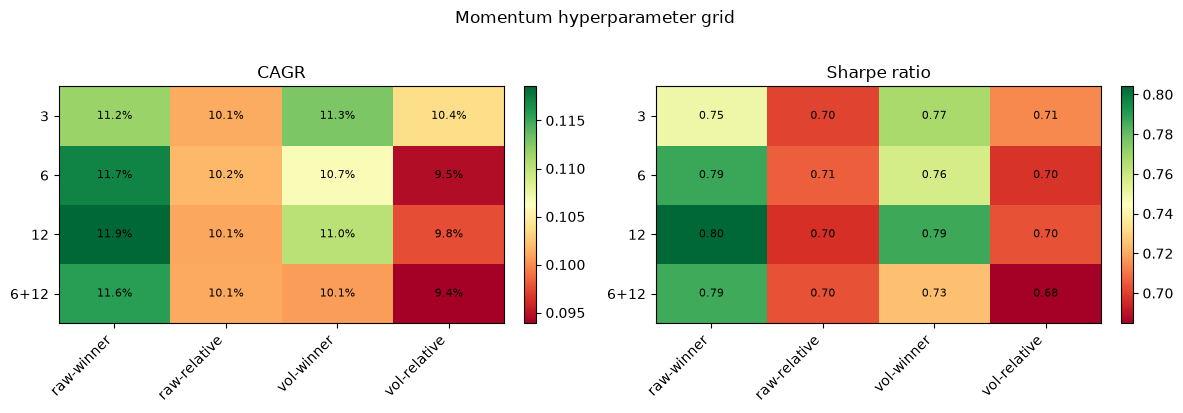

In [7]:
HEATMAP_CONFIGS = {
    (3, False, "winner"): {"lookbacks": (3,), "allocation": "winner"},
    (6, False, "winner"): {"lookbacks": (6,), "allocation": "winner"},
    (12, False, "winner"): {"lookbacks": (12,), "allocation": "winner"},
    ((6, 12), False, "winner"): {"lookbacks": (6, 12), "allocation": "winner"},
    (3, False, "relative"): {"lookbacks": (3,), "allocation": "relative"},
    (6, False, "relative"): {"lookbacks": (6,), "allocation": "relative"},
    (12, False, "relative"): {"lookbacks": (12,), "allocation": "relative"},
    ((6, 12), False, "relative"): {"lookbacks": (6, 12), "allocation": "relative"},
    (3, True, "winner"): {"lookbacks": (3,), "vol_scaled": True, "allocation": "winner"},
    (6, True, "winner"): {"lookbacks": (6,), "vol_scaled": True, "allocation": "winner"},
    (12, True, "winner"): {"lookbacks": (12,), "vol_scaled": True, "allocation": "winner"},
    ((6, 12), True, "winner"): {"lookbacks": (6, 12), "vol_scaled": True, "allocation": "winner"},
    (3, True, "relative"): {"lookbacks": (3,), "vol_scaled": True, "allocation": "relative"},
    (6, True, "relative"): {"lookbacks": (6,), "vol_scaled": True, "allocation": "relative"},
    (12, True, "relative"): {"lookbacks": (12,), "vol_scaled": True, "allocation": "relative"},
    ((6, 12), True, "relative"): {"lookbacks": (6, 12), "vol_scaled": True, "allocation": "relative"},
}


def _lookback_label(lb: int | tuple[int, ...]) -> str:
    if isinstance(lb, tuple):
        return "+".join(str(x) for x in lb)
    return str(lb)


heatmap_rows: list[dict] = []
for (lookback, vol_scaled, allocation), cfg in HEATMAP_CONFIGS.items():
    weights = momentum_weights(prices, **cfg)
    result = run_backtest(prices, weights, config)
    metrics = summary(result).iloc[0]
    heatmap_rows.append(
        {
            "lookback": _lookback_label(lookback),
            "variant": f"{'vol' if vol_scaled else 'raw'}-{allocation}",
            "cagr": metrics["cagr"],
            "sharpe_ratio": metrics["sharpe_ratio"],
        }
    )

heatmap_df = pd.DataFrame(heatmap_rows)
lookback_order = ["3", "6", "12", "6+12"]
variant_order = ["raw-winner", "raw-relative", "vol-winner", "vol-relative"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title in zip(
    axes,
    ["cagr", "sharpe_ratio"],
    ["CAGR", "Sharpe ratio"],
    strict=True,
):
    pivot = heatmap_df.pivot(index="lookback", columns="variant", values=metric)
    pivot = pivot.reindex(index=lookback_order, columns=variant_order)
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(title)
    for i, row in enumerate(pivot.values):
        for j, val in enumerate(row):
            if np.isnan(val):
                continue
            fmt = f"{val:.1%}" if metric == "cagr" else f"{val:.2f}"
            ax.text(j, i, fmt, ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Momentum hyperparameter grid", y=1.02)
fig.tight_layout()
plt.show()

## Allocation over time (default 12m winner)

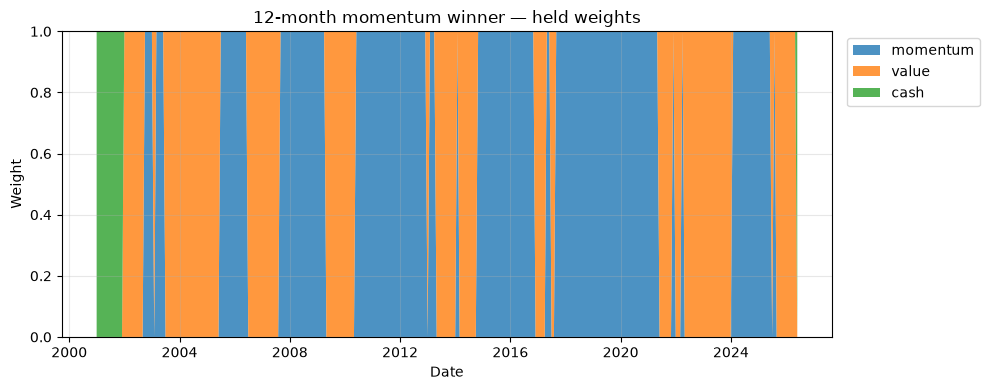

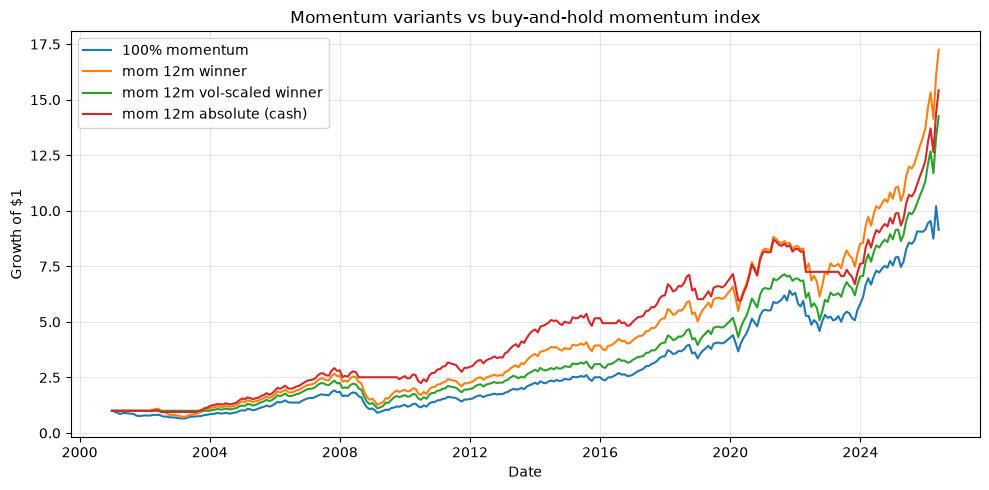

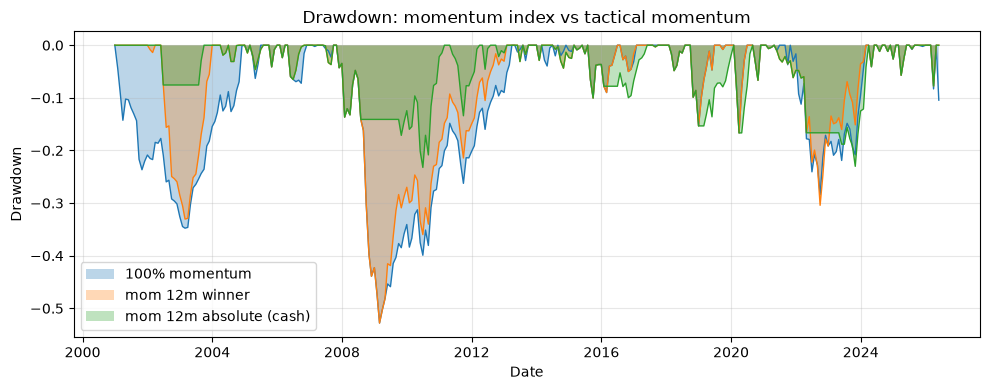

In [8]:
plot_allocation(results["mom 12m winner"], title="12-month momentum winner — held weights")
plt.show()

plot_equity_curve(
    {
        "100% momentum": results["100% momentum"],
        "mom 12m winner": results["mom 12m winner"],
        "mom 12m vol-scaled winner": results["mom 12m vol-scaled winner"],
        "mom 12m absolute (cash)": results["mom 12m absolute (cash)"],
    },
    title="Momentum variants vs buy-and-hold momentum index",
)
plt.show()

plot_drawdown(
    {
        "100% momentum": results["100% momentum"],
        "mom 12m winner": results["mom 12m winner"],
        "mom 12m absolute (cash)": results["mom 12m absolute (cash)"],
    },
    title="Drawdown: momentum index vs tactical momentum",
)
plt.show()

## Walk-forward evaluation

The hyperparameter heatmap above scores every configuration on the **full sample** (in-sample), which tends to overfit. Walk-forward evaluation avoids that by:

1. **Training** (expanding window): pick the best parameter set using only past data
2. **Testing** (OOS window): apply the winner for the next `test_months` months
3. **Stitch** all OOS segments into one continuous backtest (taxes and holdings carry across folds)

Default: 60-month minimum train, 12-month test steps, Sharpe as the selection objective.

In [ ]:
PARAM_GRID = {
    "mom 12m winner": {"lookbacks": (12,), "allocation": "winner"},
    "mom 6m winner": {"lookbacks": (6,), "allocation": "winner"},
    "mom 3m winner": {"lookbacks": (3,), "allocation": "winner"},
    "mom 6+12 blend winner": {"lookbacks": (6, 12), "allocation": "winner"},
    "mom 12m vol-scaled winner": {
        "lookbacks": (12,),
        "vol_scaled": True,
        "allocation": "winner",
    },
    "mom 12m relative": {"lookbacks": (12,), "allocation": "relative"},
    "mom 12m absolute (cash)": {
        "lookbacks": (12,),
        "allocation": "winner",
        "absolute": True,
    },
}

wf = walk_forward(
    prices_full,
    PARAM_GRID,
    objective="sharpe",
    train_min_months=60,
    test_months=12,
    config=config,
)

print(
    f"Walk-forward: {len(wf.folds)} folds | "
    f"OOS window {wf.oos_result.equity.index[0].date()} -> "
    f"{wf.oos_result.equity.index[-1].date()} ({len(wf.oos_result.equity)} months)"
)
wf.selections

In [ ]:
from asset_allocation.metrics import sharpe_ratio

oos_start = wf.oos_result.equity.index[0]
oos_prices = prices_full.loc[oos_start:]

# In-sample best: pick on full history, then slice to OOS span (optimistic benchmark)
in_sample_scores: dict[str, float] = {}
for name, params in PARAM_GRID.items():
    weights = momentum_weights(prices_full, **params)
    result = run_backtest(prices_full, weights, config)
    in_sample_scores[name] = sharpe_ratio(
        result.returns, config.risk_free_rate, config.periods_per_year
    )

best_in_sample = max(in_sample_scores, key=in_sample_scores.get)
best_is_weights = momentum_weights(prices_full, **PARAM_GRID[best_in_sample])
best_is_result = run_backtest(oos_prices, best_is_weights.loc[oos_start:], config)

bh_weights = buy_and_hold_weights(oos_prices, {"momentum": 0.5, "value": 0.5})
bh_result = run_backtest(oos_prices, bh_weights, config)

comparison = {
    "walk-forward OOS": wf.oos_result,
    f"in-sample best ({best_in_sample})": best_is_result,
    "50/50 buy-and-hold": bh_result,
}

comparison_summary = pd.concat([summary(r, name) for name, r in comparison.items()])
comparison_summary.style.format(
    {
        "total_return": "{:.1%}",
        "cagr": "{:.1%}",
        "annual_volatility": "{:.1%}",
        "sharpe_ratio": "{:.2f}",
        "sortino_ratio": "{:.2f}",
        "calmar_ratio": "{:.2f}",
        "max_drawdown": "{:.1%}",
        "best_month": "{:.1%}",
        "worst_month": "{:.1%}",
        "win_rate": "{:.1%}",
        "annual_turnover": "{:.2f}",
        "time_in_market": "{:.1%}",
    }
)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_equity_curve(
    comparison,
    ax=axes[0],
    title="Walk-forward OOS vs in-sample best",
)
plot_drawdown(
    comparison,
    ax=axes[1],
    title="Drawdown comparison (OOS window)",
)
fig.tight_layout()
plt.show()

In [ ]:
def _lookback_label(params: dict) -> str:
    lb = params.get("lookbacks", ())
    if len(lb) == 1:
        return str(lb[0])
    return "+".join(str(x) for x in lb)


selection_timeline = wf.selections.copy()
selection_timeline["lookback"] = selection_timeline["selected"].map(
    lambda name: _lookback_label(PARAM_GRID[name])
)

fig, ax = plt.subplots(figsize=(12, 3))
ax.step(
    selection_timeline.index,
    selection_timeline["lookback"],
    where="post",
    linewidth=1.5,
)
ax.set_title("Selected momentum lookback over walk-forward folds")
ax.set_xlabel("OOS test start")
ax.set_ylabel("Lookback (months)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()